### Sprint 2 — Semana 5
### Fecha: 15/05/2026

---

## Objetivo

Generar reportes visuales y evidencia experimental del modelo baseline oficial `obra_v4`, incluyendo:

- métricas oficiales
- matriz de confusión
- feature importance
- comparación de modelos
- artefactos gráficos para documentación y sustentación

---

## Artefactos generados

- confusion_matrix_rf_tuned.png
- feature_importance_rf.png
- model_comparison.png
- feature_importance_rf_obra_v4.csv

---

## Autor

Fernando García Atúncar  
Maestría en Inteligencia Artificial – UNI

### Reortes y Visualización

In [1]:
# ============================================================
# PASO 1 — IMPORTS Y CARGA DE ARTEFACTOS
# ============================================================

import json
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Configuración visual
# ------------------------------------------------------------

plt.style.use("default")

sns.set_theme(style="whitegrid")

# ============================================================
# CARGA DATASET
# ============================================================

DATA_PATH = "../data/processed/dataset_obra_v4_model.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado:", df.shape)

# ============================================================
# CARGA MODELO
# ============================================================

MODEL_PATH = "../models/obra_v4/pipeline_rf_obra_v4.pkl"

model = joblib.load(MODEL_PATH)

print("Modelo cargado correctamente")

# ============================================================
# CARGA MÉTRICAS
# ============================================================

METRICS_PATH = "../models/obra_v4/metrics_rf_obra_v4.json"

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

print("Métricas cargadas")

# ============================================================
# MOSTRAR MÉTRICAS
# ============================================================

metrics

Dataset cargado: (326, 33)
Modelo cargado correctamente
Métricas cargadas


{'model_name': 'RandomForest_obra_v4',
 'dataset': 'obra_v4',
 'n_features': 31,
 'n_train': 260,
 'n_test': 66,
 'accuracy': 0.5757575757575758,
 'balanced_accuracy': 0.4123232323232323,
 'macro_f1': 0.4267857142857142,
 'weighted_f1': 0.5762987012987013,
 'best_params': {'model__bootstrap': False,
  'model__max_depth': 10,
  'model__max_features': 'log2',
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 5,
  'model__n_estimators': 661}}

### RECONSTRUIR X_test e y_test

In [2]:
# ============================================================
# RECONSTRUIR HOLDOUT OFICIAL
# ============================================================

TARGET = "y_riesgo_obra_5niveles"

# ------------------------------------------------------------
# Variables a excluir
# ------------------------------------------------------------

drop_cols = [
    "IDENTIFICADOR_OBRA"
]

drop_cols = [c for c in drop_cols if c in df.columns]

# ------------------------------------------------------------
# X / y
# ------------------------------------------------------------

X = df.drop(columns=[TARGET] + drop_cols)

y = df[TARGET]

# ------------------------------------------------------------
# Split oficial
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*60)
print("HOLDOUT RECONSTRUIDO")
print("="*60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nDistribución y_test:")
print(y_test.value_counts().sort_index())

HOLDOUT RECONSTRUIDO
X_train: (260, 31)
X_test : (66, 31)

Distribución y_test:
y_riesgo_obra_5niveles
0     6
1    11
2    18
3     1
4    30
Name: count, dtype: int64


### PREDICCIONES

In [3]:
# ============================================================
# PREDICCIONES
# ============================================================

# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Distribución predicciones
# ------------------------------------------------------------

print("\n")
print("="*70)
print("DISTRIBUCIÓN PREDICCIONES")
print("="*70)

pred_dist = pd.Series(y_pred).value_counts().sort_index()

print(pred_dist)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.60      0.27      0.38        11
           2       0.59      0.56      0.57        18
           3       0.00      0.00      0.00         1
           4       0.65      0.73      0.69        30

    accuracy                           0.58        66
   macro avg       0.47      0.41      0.43        66
weighted avg       0.60      0.58      0.58        66



DISTRIBUCIÓN PREDICCIONES
0     6
1     5
2    17
3     4
4    34
Name: count, dtype: int64


### MATRIZ DE CONFUSIÓN

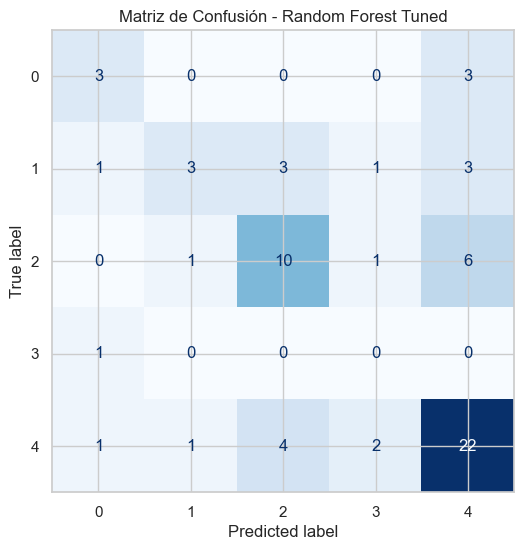


Figura guardada en:
../reports/figures/confusion_matrix_rf_tuned.png


In [4]:
# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de Confusión - Random Forest Tuned")

# ------------------------------------------------------------
# Guardar figura
# ------------------------------------------------------------

OUTPUT_PATH = "../reports/figures/confusion_matrix_rf_tuned.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigura guardada en:")
print(OUTPUT_PATH)

### FEATURE IMPORTANCE

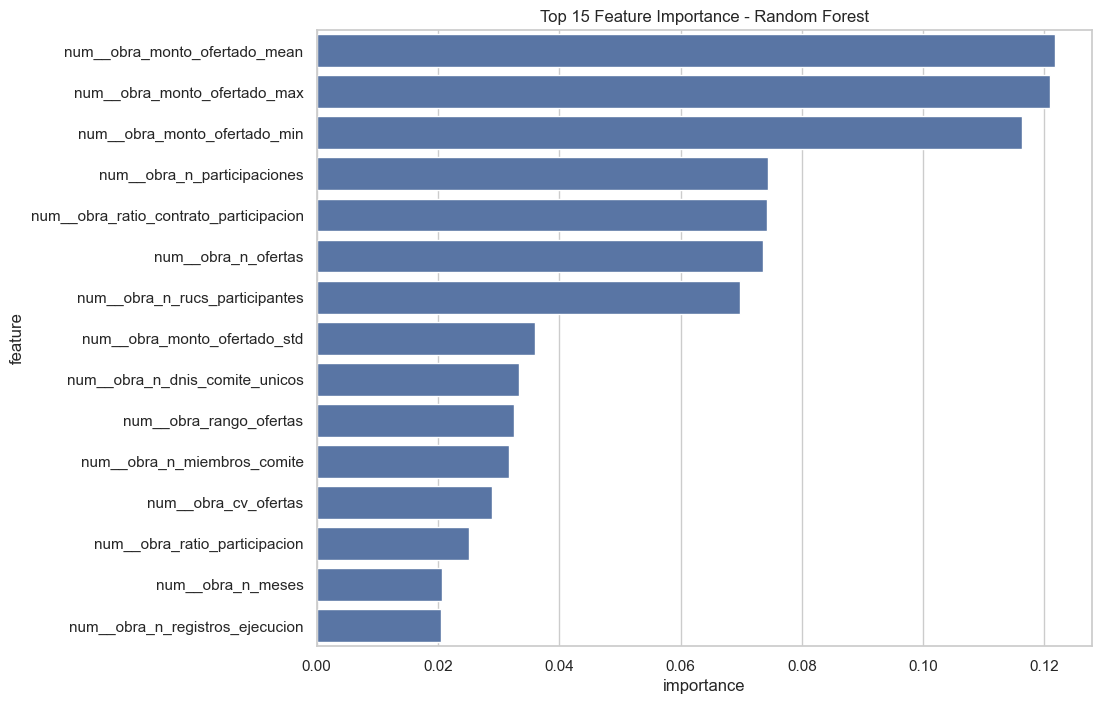


Figura guardada en:
../reports/figures/feature_importance_rf.png

CSV guardado en:
../models/obra_v4/feature_importance_rf_obra_v4.csv


,feature,importance
12,num__obra_monto_ofertado_mean,0.121728
15,num__obra_monto_ofertado_max,0.120926
14,num__obra_monto_ofertado_min,0.116276
5,num__obra_n_participaciones,0.074385
11,num__obra_ratio_contrato_participacion,0.074177
16,num__obra_n_ofertas,0.073610
6,num__obra_n_rucs_participantes,0.069870
13,num__obra_monto_ofertado_std,0.035975
1,num__obra_n_dnis_comite_unicos,0.033346
17,num__obra_rango_ofertas,0.032518


In [5]:
# ============================================================
# FEATURE IMPORTANCE RF
# ============================================================

# ------------------------------------------------------------
# Obtener modelo interno RF
# ------------------------------------------------------------

rf_model = model.named_steps["model"]

# ------------------------------------------------------------
# Obtener nombres de features transformadas
# ------------------------------------------------------------

prep = model.named_steps["prep"]

feature_names = prep.get_feature_names_out()

# ------------------------------------------------------------
# Importancias
# ------------------------------------------------------------

importances = rf_model.feature_importances_

# ------------------------------------------------------------
# DataFrame importance
# ------------------------------------------------------------

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_df = fi_df.sort_values(
    by="importance",
    ascending=False
)

# ------------------------------------------------------------
# Top 15
# ------------------------------------------------------------

top_fi = fi_df.head(15)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_fi,
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importance - Random Forest")

# ------------------------------------------------------------
# Guardar figura
# ------------------------------------------------------------

OUTPUT_PATH = "../reports/figures/feature_importance_rf.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Guardar CSV
# ------------------------------------------------------------

CSV_PATH = "../models/obra_v4/feature_importance_rf_obra_v4.csv"

fi_df.to_csv(
    CSV_PATH,
    index=False
)

print("\nFigura guardada en:")
print(OUTPUT_PATH)

print("\nCSV guardado en:")
print(CSV_PATH)

# ------------------------------------------------------------
# Mostrar top features
# ------------------------------------------------------------

top_fi

##### Las variables con mayor importancia predictiva estuvieron asociadas principalmente a montos ofertados, participación empresarial y dinámica de competencia, lo cual sugiere que el comportamiento económico de los procesos contiene señales relevantes de riesgo.

### GENERAR COMPARACIÓN DE MODELOS

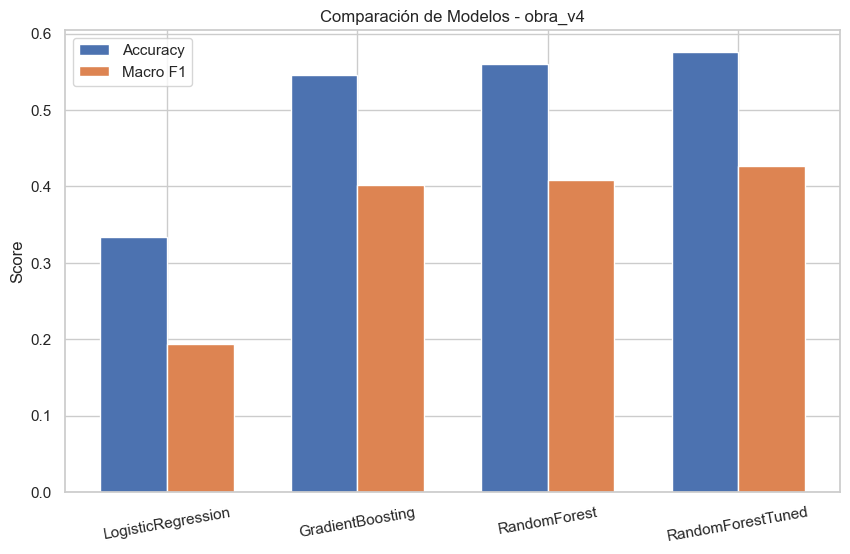


Figura guardada en:
../reports/figures/model_comparison.png


,modelo,accuracy,macro_f1
0,LogisticRegression,0.333333,0.193287
1,GradientBoosting,0.545455,0.402424
2,RandomForest,0.560606,0.408274
3,RandomForestTuned,0.575758,0.426786


In [6]:
# ============================================================
# COMPARACIÓN DE MODELOS
# ============================================================

# ------------------------------------------------------------
# DataFrame resultados - Obtenidos del Sprint 1 - Resultados
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "modelo": [
        "LogisticRegression",
        "GradientBoosting",
        "RandomForest",
        "RandomForestTuned"
    ],
    "accuracy": [
        0.333333,
        0.545455,
        0.560606,
        0.575758
    ],
    "macro_f1": [
        0.193287,
        0.402424,
        0.408274,
        0.426786
    ]
})

# ------------------------------------------------------------
# Ordenar
# ------------------------------------------------------------

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=True
)

# ------------------------------------------------------------
# Plot Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

x = np.arange(len(results_df))

width = 0.35

plt.bar(
    x - width/2,
    results_df["accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    results_df["macro_f1"],
    width,
    label="Macro F1"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xticks(
    x,
    results_df["modelo"],
    rotation=10
)

plt.ylabel("Score")

plt.title("Comparación de Modelos - obra_v4")

plt.legend()

# ------------------------------------------------------------
# Guardar figura
# ------------------------------------------------------------

OUTPUT_PATH = "../reports/figures/model_comparison.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigura guardada en:")
print(OUTPUT_PATH)

# ------------------------------------------------------------
# Mostrar tabla
# ------------------------------------------------------------

results_df